# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_genes = 1000
expressao = np.random.normal(loc=0, scale=1, size=n_genes)

df = pd.DataFrame({
    'Gene': [f'Gene_{i+1}' for i in range(n_genes)],
    'Expressao': expressao
})

upregulated = df[df['Expressao'] > 0]
downregulated = df[df['Expressao'] < 0]
neutros = df[df['Expressao'] == 0]

print(f"Total de genes: {n_genes}")
print(f"Upregulated (>0): {len(upregulated)} genes")
print(f"Downregulated (<0): {len(downregulated)} genes")
print(f"Neutros (=0): {len(neutros)} genes")
print(f"\nPrimeiros 10 genes:")
print(df.head(10))

Total de genes: 1000
Upregulated (>0): 510 genes
Downregulated (<0): 490 genes
Neutros (=0): 0 genes

Primeiros 10 genes:
      Gene  Expressao
0   Gene_1   0.496714
1   Gene_2  -0.138264
2   Gene_3   0.647689
3   Gene_4   1.523030
4   Gene_5  -0.234153
5   Gene_6  -0.234137
6   Gene_7   1.579213
7   Gene_8   0.767435
8   Gene_9  -0.469474
9  Gene_10   0.542560


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_pacientes = 1000

upregulated = np.random.randint(0, 100, n_pacientes)
downregulated = np.random.randint(0, 100, n_pacientes)

df = pd.DataFrame({
    'Paciente': [f'Paciente_{i+1}' for i in range(n_pacientes)],
    'Genes_Up': upregulated,
    'Genes_Down': downregulated
})

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

      Paciente  Genes_Up  Genes_Down
0   Paciente_1        51          33
1   Paciente_2        92           7
2   Paciente_3        14          39
3   Paciente_4        71          82
4   Paciente_5        60          41
5   Paciente_6        20          40
6   Paciente_7        82           5
7   Paciente_8        86          51
8   Paciente_9        74          25
9  Paciente_10        74          63

Shape: (1000, 3)
Colunas: ['Paciente', 'Genes_Up', 'Genes_Down']


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: 

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_pacientes = 1000

upregulated = np.random.randint(0, 100, n_pacientes)
downregulated = np.random.randint(0, 100, n_pacientes)

df = pd.DataFrame({
    'Paciente': [f'Paciente_{i+1}' for i in range(n_pacientes)],
    'Genes_Up': upregulated,
    'Genes_Down': downregulated
})

df['Diferenca'] = df['Genes_Up'] - df['Genes_Down']
df['Total_DE'] = df['Genes_Up'] + df['Genes_Down']

bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto', 'Extremo']
df['Categoria_Up'] = pd.cut(df['Genes_Up'], bins=bins, labels=labels)

df['Categoria_Down'] = pd.cut(df['Genes_Down'], bins=bins, labels=labels)

categorias_up = df.groupby('Categoria_Up').size()
categorias_down = df.groupby('Categoria_Down').size()

print("Categorias para Genes Upregulated:")
print(categorias_up)
print("\nCategorias para Genes Downregulated:")
print(categorias_down)
print("\nPrimeiros 15 pacientes:")
print(df.head(15))

Categorias para Genes Upregulated:
Categoria_Up
Muito Baixo    207
Baixo          193
Médio          202
Alto           178
Muito Alto     204
Extremo          0
dtype: int64

Categorias para Genes Downregulated:
Categoria_Down
Muito Baixo    204
Baixo          216
Médio          189
Alto           187
Muito Alto     194
Extremo          0
dtype: int64

Primeiros 15 pacientes:
       Paciente  Genes_Up  Genes_Down  Diferenca  Total_DE Categoria_Up  \
0    Paciente_1        51          33         18        84        Médio   
1    Paciente_2        92           7         85        99   Muito Alto   
2    Paciente_3        14          39        -25        53  Muito Baixo   
3    Paciente_4        71          82        -11       153         Alto   
4    Paciente_5        60          41         19       101        Médio   
5    Paciente_6        20          40        -20        60  Muito Baixo   
6    Paciente_7        82           5         77        87   Muito Alto   
7    Paciente_8     

C:\Users\Camilla\AppData\Local\Temp\ipykernel_4088\215243428.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categorias_up = df.groupby('Categoria_Up').size()
C:\Users\Camilla\AppData\Local\Temp\ipykernel_4088\215243428.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categorias_down = df.groupby('Categoria_Down').size()


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [4]:
import numpy as np
import pandas as pd

def tabela_frequencia(serie):
    freq_abs = serie.value_counts().sort_index()
    freq_rel = (freq_abs / len(serie)) * 100
    return pd.DataFrame({
        'Frequencia': freq_abs,
        'Freq_Relativa(%)': freq_rel
    })

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

print(tabela_frequencia(pd.Series(expressao.round(2))).head(10))
print("\n", tabela_frequencia(pd.Series(up)).head(10))
print("\n", tabela_frequencia(pd.Series(down)).head(10))

       Frequencia  Freq_Relativa(%)
-3.24           1               0.1
-2.70           1               0.1
-2.65           1               0.1
-2.62           1               0.1
-2.47           1               0.1
-2.42           1               0.1
-2.30           1               0.1
-2.21           1               0.1
-2.20           1               0.1
-2.12           1               0.1

    Frequencia  Freq_Relativa(%)
0          10               1.0
1          16               1.6
2          11               1.1
3          12               1.2
4          13               1.3
5           9               0.9
6          10               1.0
7          19               1.9
8           7               0.7
9          13               1.3

    Frequencia  Freq_Relativa(%)
0           9               0.9
1           6               0.6
2          12               1.2
3          11               1.1
4           6               0.6
5           7               0.7
6           7           

## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

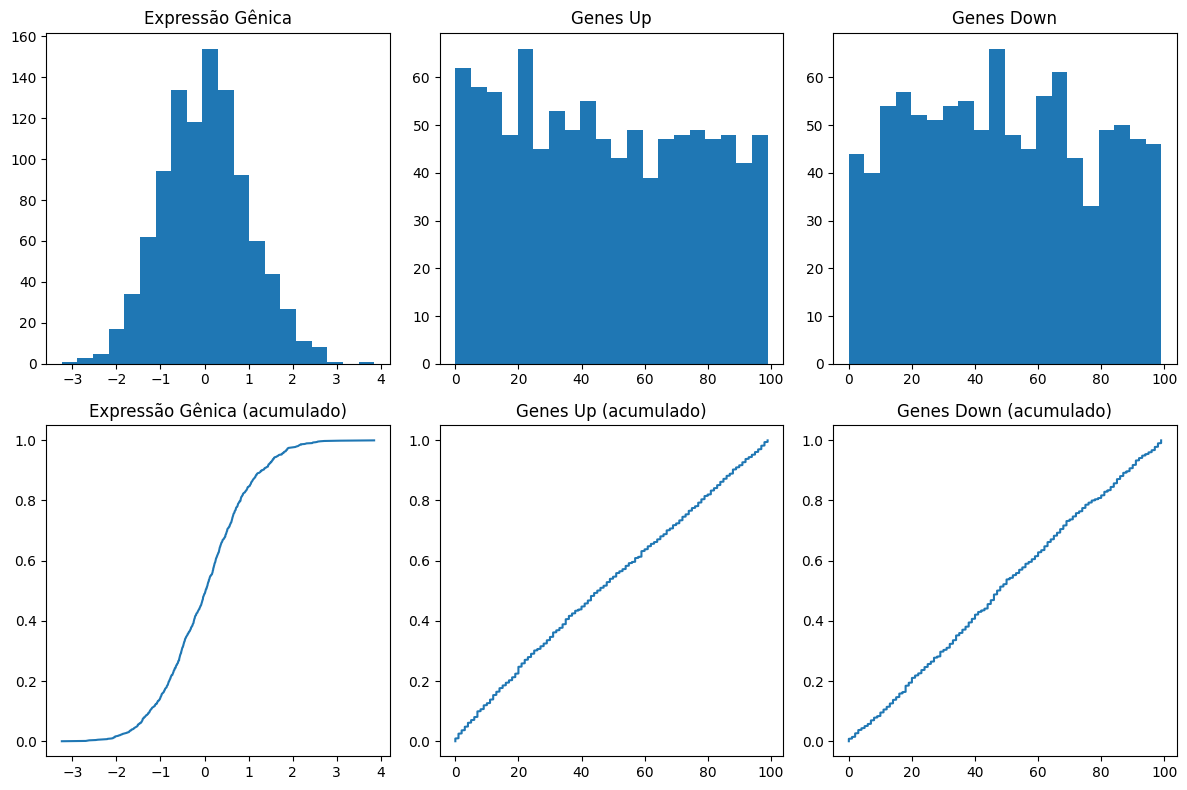

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].hist(expressao, bins=20)
axes[0, 0].set_title('Expressão Gênica')

axes[0, 1].hist(up, bins=20)
axes[0, 1].set_title('Genes Up')

axes[0, 2].hist(down, bins=20)
axes[0, 2].set_title('Genes Down')

axes[1, 0].plot(np.sort(expressao), np.arange(len(expressao))/len(expressao))
axes[1, 0].set_title('Expressão Gênica (acumulado)')

axes[1, 1].plot(np.sort(up), np.arange(len(up))/len(up))
axes[1, 1].set_title('Genes Up (acumulado)')

axes[1, 2].plot(np.sort(down), np.arange(len(down))/len(down))
axes[1, 2].set_title('Genes Down (acumulado)')

plt.tight_layout()
plt.show()

### Expressão

### Número

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

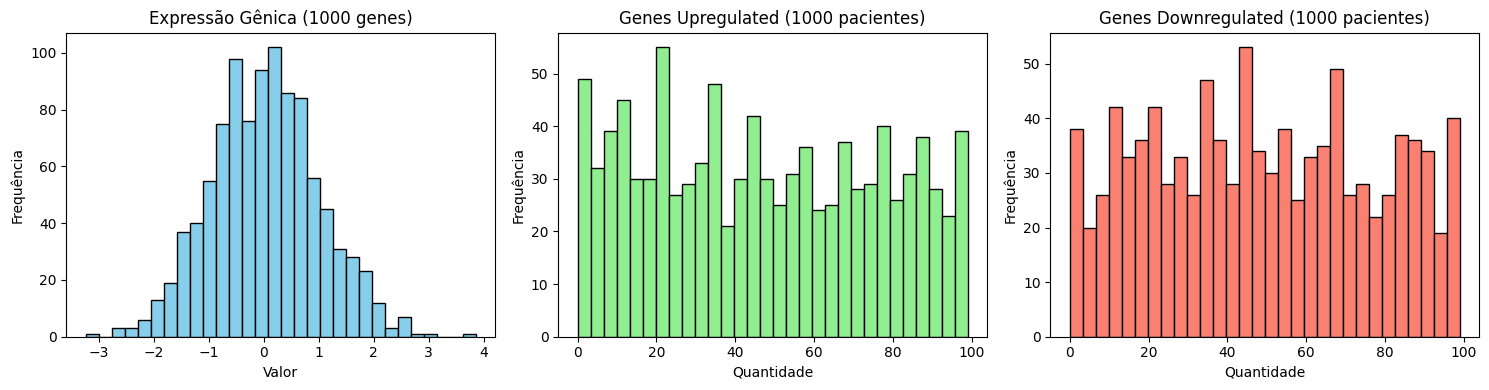

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(expressao, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Expressão Gênica (1000 genes)')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frequência')

axes[1].hist(up, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Genes Upregulated (1000 pacientes)')
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('Frequência')

axes[2].hist(down, bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Genes Downregulated (1000 pacientes)')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

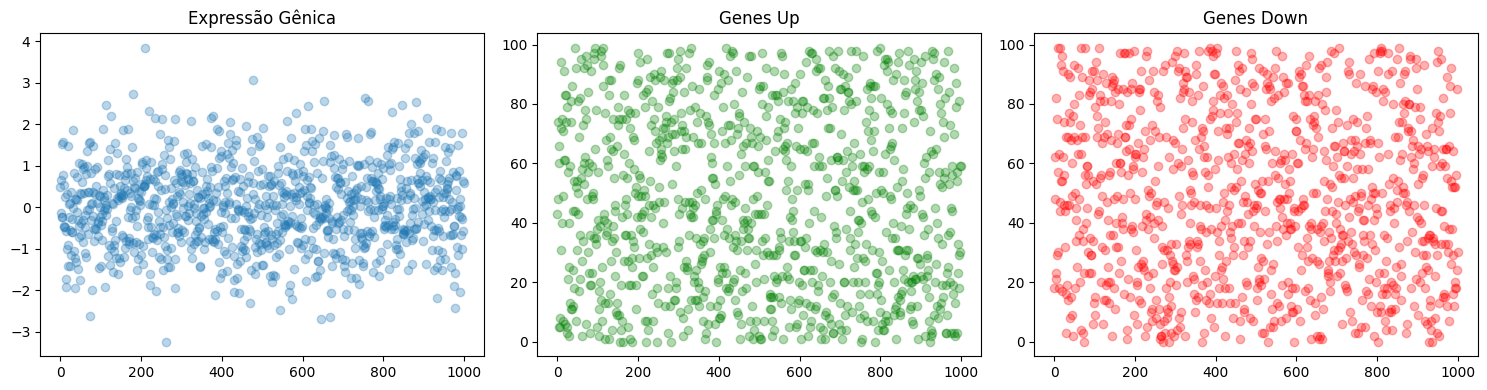

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(range(1000), expressao, alpha=0.3)
plt.title('Expressão Gênica')

plt.subplot(1, 3, 2)
plt.scatter(range(1000), up, alpha=0.3, color='green')
plt.title('Genes Up')

plt.subplot(1, 3, 3)
plt.scatter(range(1000), down, alpha=0.3, color='red')
plt.title('Genes Down')

plt.tight_layout()
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

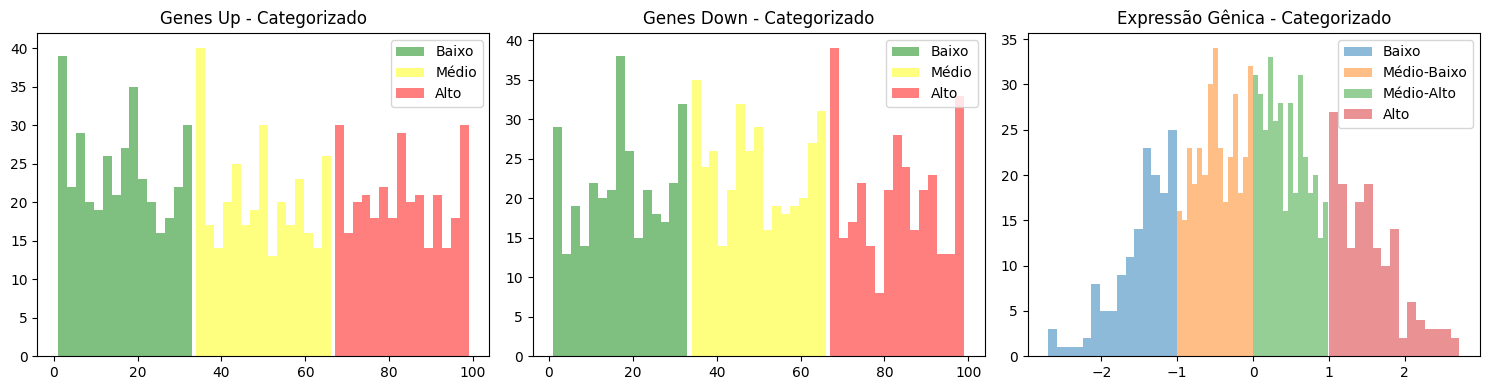

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

categorias_up = pd.cut(up, bins=[0, 33, 66, 100], labels=['Baixo', 'Médio', 'Alto'])
categorias_down = pd.cut(down, bins=[0, 33, 66, 100], labels=['Baixo', 'Médio', 'Alto'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cores = {'Baixo': 'green', 'Médio': 'yellow', 'Alto': 'red'}

for cat in categorias_up.categories:
    mask = categorias_up == cat
    axes[0].hist(up[mask], bins=15, alpha=0.5, label=cat, color=cores[cat])
axes[0].set_title('Genes Up - Categorizado')
axes[0].legend()

for cat in categorias_down.categories:
    mask = categorias_down == cat
    axes[1].hist(down[mask], bins=15, alpha=0.5, label=cat, color=cores[cat])
axes[1].set_title('Genes Down - Categorizado')
axes[1].legend()

categorias_exp = pd.cut(expressao, bins=[-3, -1, 0, 1, 3], labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto'])
for cat in categorias_exp.categories:
    mask = categorias_exp == cat
    axes[2].hist(expressao[mask], bins=15, alpha=0.5, label=cat)
axes[2].set_title('Expressão Gênica - Categorizado')
axes[2].legend()

plt.tight_layout()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

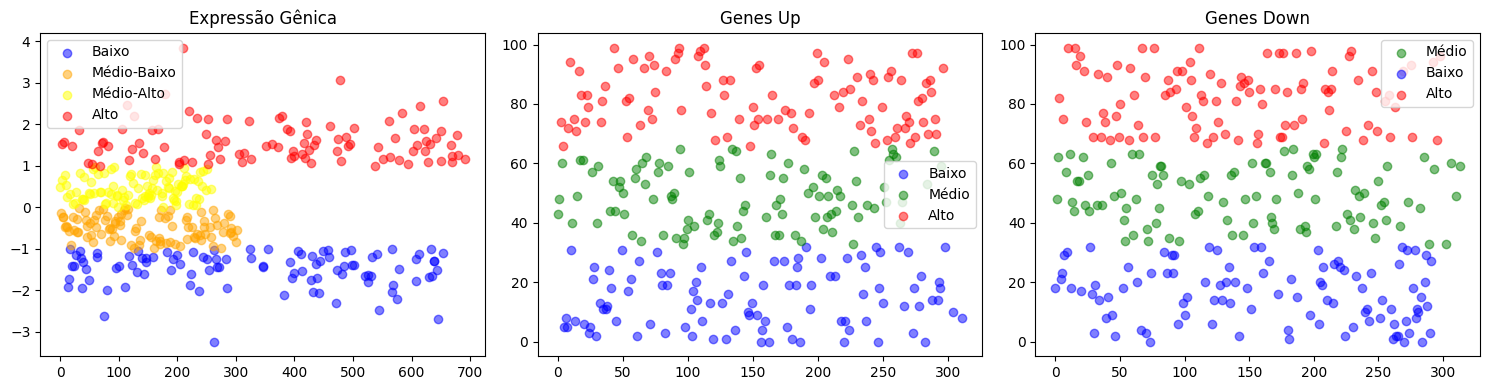

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

expressao = np.random.normal(0, 1, 1000)
up = np.random.randint(0, 100, 1000)
down = np.random.randint(0, 100, 1000)

categorias_up = np.where(up < 33, 'Baixo', np.where(up < 66, 'Médio', 'Alto'))
categorias_down = np.where(down < 33, 'Baixo', np.where(down < 66, 'Médio', 'Alto'))
categorias_exp = np.where(expressao < -1, 'Baixo', np.where(expressao < 0, 'Médio-Baixo', np.where(expressao < 1, 'Médio-Alto', 'Alto')))

cores = {'Baixo': 'blue', 'Médio': 'green', 'Alto': 'red', 'Médio-Baixo': 'orange', 'Médio-Alto': 'yellow'}

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
for cat in set(categorias_exp):
    mask = categorias_exp == cat
    plt.scatter(np.where(mask)[0][:100], expressao[mask][:100], alpha=0.5, color=cores.get(cat, 'gray'), label=cat)
plt.title('Expressão Gênica')
plt.legend()

plt.subplot(1, 3, 2)
for cat in set(categorias_up):
    mask = categorias_up == cat
    plt.scatter(np.where(mask)[0][:100], up[mask][:100], alpha=0.5, color=cores.get(cat, 'gray'), label=cat)
plt.title('Genes Up')
plt.legend()

plt.subplot(1, 3, 3)
for cat in set(categorias_down):
    mask = categorias_down == cat
    plt.scatter(np.where(mask)[0][:100], down[mask][:100], alpha=0.5, color=cores.get(cat, 'gray'), label=cat)
plt.title('Genes Down')
plt.legend()

plt.tight_layout()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

In [11]:
import pandas as pd
import numpy as np

dados = pd.DataFrame({
    '#_celulas': np.random.randint(0, 100, 10),
    '%_celulas': np.random.uniform(0, 100, 10).round(1),
    'faixa_pH': [f"{np.random.uniform(5,7):.1f}-{np.random.uniform(7,9):.1f}" for _ in range(10)],
    'pH': np.random.uniform(5, 8, 10).round(1),
    'mol/L': np.random.uniform(0.01, 1, 10).round(3),
    'UFC': np.random.randint(100, 10000, 10),
    'DO': np.random.uniform(0, 2, 10).round(3),
    'grupo': np.random.choice(['A', 'B', 'AB', 'O'], 10),
    'sorologia': np.random.choice(['Reagente', 'Nao Reagente'], 10)
})

print(dados)
print("\nTipos:", dados.dtypes)

   #_celulas  %_celulas faixa_pH   pH  mol/L   UFC     DO grupo     sorologia
0         80        7.2  5.5-8.0  6.1  0.098  9220  1.288     O  Nao Reagente
1         54       68.3  5.6-7.3  5.8  0.690  3707  0.096    AB      Reagente
2         22       24.2  6.3-7.1  7.5  0.499  8143  0.720     A      Reagente
3         31       71.4  6.5-7.6  5.9  0.394   622  1.914     A  Nao Reagente
4         61       82.3  5.0-8.0  7.4  0.636  6004  1.001     B      Reagente
5         73       80.4  5.1-7.6  7.7  0.707  4988  0.865     A  Nao Reagente
6          9       55.3  6.4-7.1  6.3  0.014  9921  0.915     A  Nao Reagente
7         99       52.0  6.7-7.0  7.7  0.175  5932  0.418     O  Nao Reagente
8         71       14.3  5.5-8.5  6.1  0.716  7222  0.737    AB      Reagente
9         53       77.5  5.6-7.2  7.9  0.670  5942  0.740     B  Nao Reagente

Tipos: #_celulas      int32
%_celulas    float64
faixa_pH      object
pH           float64
mol/L        float64
UFC            int32
DO      